In [18]:
import synthetic_data, confidence_intervals
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

In [19]:
eps = 0.8
q = 1
alpha = 0.05
n = 5000

rng = np.random.default_rng()

In [20]:
trunc = synthetic_data.generate_truncated_samples_gaussian(n, eps, q, alpha, rng)

In [21]:
n_list = np.logspace(2,7)
fixed_eps_dict = {}
opt_up = []
opt_low = []
uppers = []
lowers = []
means = []
means_upper = []
means_lower = []
maxmin = []
for n in n_list:
  n = int(n)
  trunc = synthetic_data.generate_truncated_samples_gaussian(n, eps, q, 1, rng)
  t = np.sqrt(max(0, (np.log(n * eps**2) - np.log(np.log(4/alpha)))/2 ))
  sim_dict = confidence_intervals.compute_CI_Gaussian(trunc, t, alpha, 1)
  uppers.append(sim_dict["right"])
  lowers.append(sim_dict["left"])
  mean = confidence_intervals.compute_sample_mean(trunc)
  means.append(confidence_intervals.compute_sample_mean(trunc))
  means_upper.append(mean + 1.96/np.sqrt(n))
  means_lower.append(mean - 1.96/np.sqrt(n))
  maxmin.append(confidence_intervals.max_min_avg(trunc))

[]

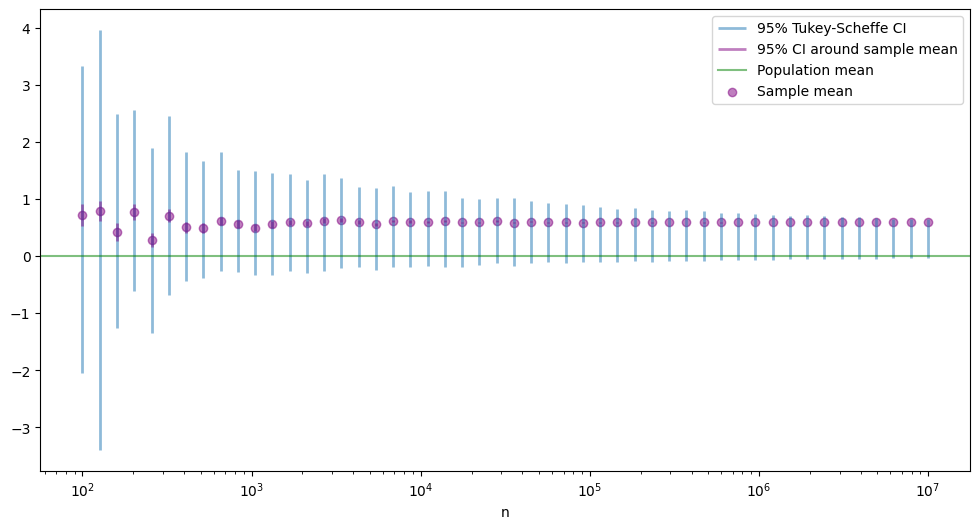

In [22]:
plt.figure(figsize=(12,6))
plt.vlines(n_list, lowers, uppers, label="95% Tukey-Scheffe CI", alpha=0.5, linewidth=2)
plt.vlines(n_list, means_lower, means_upper, label="95% CI around sample mean", color='purple', alpha=0.5,linewidth=2)
plt.axhline(0,color='green', alpha = 0.5, label="Population mean")
plt.scatter(n_list,means, color='purple', alpha = 0.5, label='Sample mean')
plt.xlabel("n")
# plt.scatter(n_list, maxmin, color='black', alpha = 0.5, label="Average of extremes")
plt.legend()
plt.semilogx()

In [23]:
q = 1

eps_list = np.linspace(0,0.99,20)
n = 800
vary_eps_dict = {}
opt_up = []
opt_low = []
uppers = []
lowers = []
means = []
means_upper = []
means_lower = []
maxmin = []
for eps in eps_list:
  trunc = synthetic_data.generate_truncated_samples_gaussian(n, eps, q, 1, rng)
  t = np.sqrt(max(0, (np.log(n * eps**2) - np.log(np.log(4/alpha)))/2 ))
  sim_dict = confidence_intervals.compute_CI_Gaussian(trunc, t, 0.05, 1)
  # opt_dict = SimulationSetting.adaptive_CI(trunc, 0.05)
  # opt_up.append(opt_dict["right"])
  # opt_low.append(opt_dict["left"])
  uppers.append(sim_dict["right"])
  lowers.append(sim_dict["left"])
  mean = confidence_intervals.compute_sample_mean(trunc)
  means.append(confidence_intervals.compute_sample_mean(trunc))
  means_upper.append(mean + 1.96/np.sqrt(n))
  means_lower.append(mean - 1.96/np.sqrt(n))
  maxmin.append(confidence_intervals.max_min_avg(trunc))

/var/folders/4l/t4phf94s3cv98dgggx2_bwj40000gn/T/ipykernel_95280/198034978.py:16: RuntimeWarning: divide by zero encountered in log
  t = np.sqrt(max(0, (np.log(n * eps**2) - np.log(np.log(4/alpha)))/2 ))


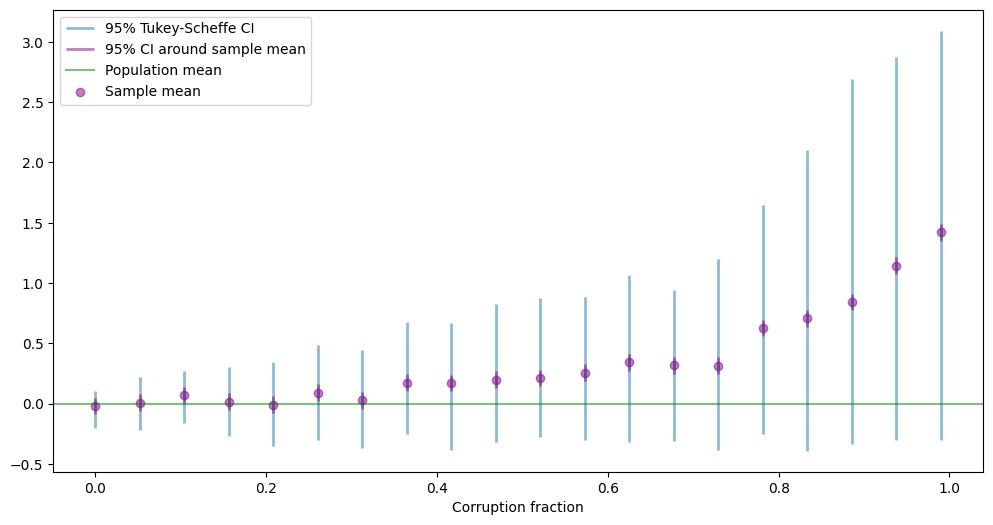

In [24]:
plt.figure(figsize=(12,6))
plt.vlines(eps_list, lowers, uppers, label="95% Tukey-Scheffe CI", alpha=0.5, linewidth=2)
plt.vlines(eps_list, means_lower, means_upper, label="95% CI around sample mean", color='purple', alpha=0.5,linewidth=2)
plt.axhline(0,color='green', alpha = 0.5, label="Population mean")
plt.scatter(eps_list,means, color='purple', alpha = 0.5, label='Sample mean')
plt.xlabel("Corruption fraction")
# plt.scatter(n_list, maxmin, color='black', alpha = 0.5, label="Average of extremes")
plt.legend(loc="upper left")

In [25]:
q = 0.5

eps_list = np.linspace(0,0.99,20)
n = 800
vary_eps_dict = {}
opt_up = []
opt_low = []
uppers = []
lowers = []
means = []
means_upper = []
means_lower = []
maxmin = []
for eps in eps_list:
  trunc = synthetic_data.generate_truncated_samples_bounded(n, eps, q, 0.5, rng)
  # t = np.sqrt(max(0, (np.log(n * eps**2) - np.log(np.log(4/alpha)))/2 ))
  sim_dict = confidence_intervals.adaptive_CI_finite_var(trunc, alpha, 1)
  # opt_dict = SimulationSetting.adaptive_CI(trunc, 0.05)
  # opt_up.append(opt_dict["right"])
  # opt_low.append(opt_dict["left"])
  uppers.append(sim_dict["right"])
  lowers.append(sim_dict["left"])
  mean = confidence_intervals.compute_sample_mean(trunc)
  means.append(confidence_intervals.compute_sample_mean(trunc))
  means_upper.append(mean + 1.96/np.sqrt(n))
  means_lower.append(mean - 1.96/np.sqrt(n))
  maxmin.append(confidence_intervals.max_min_avg(trunc))

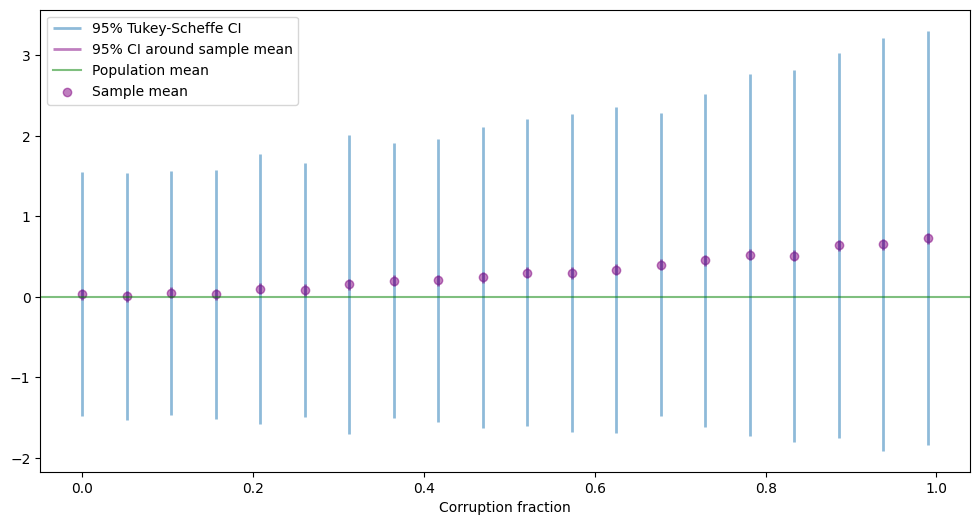

In [26]:
plt.figure(figsize=(12,6))
plt.vlines(eps_list, lowers, uppers, label="95% Tukey-Scheffe CI", alpha=0.5, linewidth=2)
plt.vlines(eps_list, means_lower, means_upper, label="95% CI around sample mean", color='purple', alpha=0.5,linewidth=2)
plt.axhline(0,color='green', alpha = 0.5, label="Population mean")
plt.scatter(eps_list,means, color='purple', alpha = 0.5, label='Sample mean')
plt.xlabel("Corruption fraction")
# plt.scatter(n_list, maxmin, color='black', alpha = 0.5, label="Average of extremes")
plt.legend(loc="upper left")

In [35]:
q = 0.5

eps_list = np.linspace(0,0.99,20)
n = 800
vary_eps_dict = {}
opt_up = []
opt_low = []
uppers = []
lowers = []
means = []
means_upper = []
means_lower = []
maxmin = []
for eps in eps_list:
  trunc = synthetic_data.generate_truncated_samples_gaussian(n, eps, q, 0.5, rng)
  # t = np.sqrt(max(0, (np.log(n * eps**2) - np.log(np.log(4/alpha)))/2 ))
  sim_dict = confidence_intervals.adaptive_CI_finite_var(trunc, alpha, 10)
  # opt_dict = SimulationSetting.adaptive_CI(trunc, 0.05)
  # opt_up.append(opt_dict["right"])
  # opt_low.append(opt_dict["left"])
  uppers.append(sim_dict["right"])
  lowers.append(sim_dict["left"])
  mean = confidence_intervals.compute_sample_mean(trunc)
  means.append(confidence_intervals.compute_sample_mean(trunc))
  means_upper.append(mean + 1.96/np.sqrt(n))
  means_lower.append(mean - 1.96/np.sqrt(n))
  maxmin.append(confidence_intervals.max_min_avg(trunc))

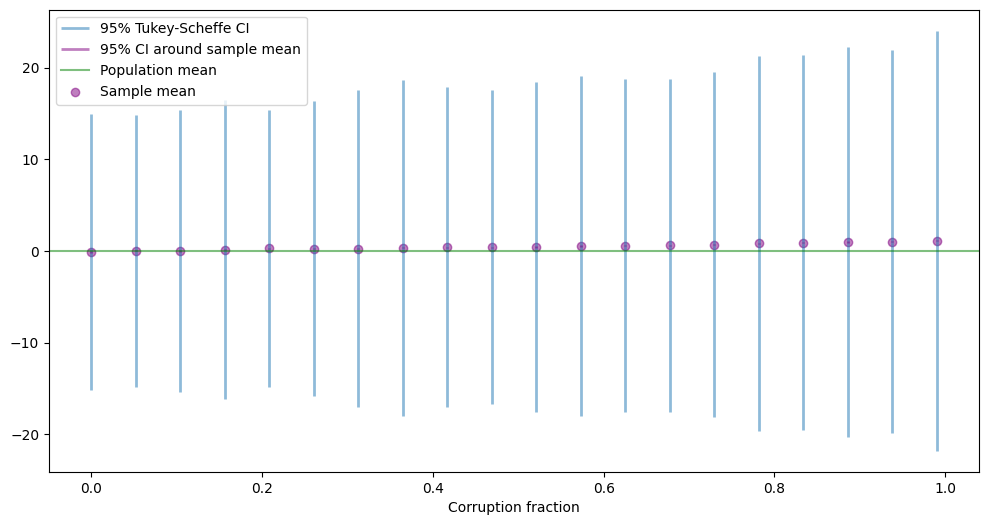

In [36]:
plt.figure(figsize=(12,6))
plt.vlines(eps_list, lowers, uppers, label="95% Tukey-Scheffe CI", alpha=0.5, linewidth=2)
plt.vlines(eps_list, means_lower, means_upper, label="95% CI around sample mean", color='purple', alpha=0.5,linewidth=2)
plt.axhline(0,color='green', alpha = 0.5, label="Population mean")
plt.scatter(eps_list,means, color='purple', alpha = 0.5, label='Sample mean')
plt.xlabel("Corruption fraction")
# plt.scatter(n_list, maxmin, color='black', alpha = 0.5, label="Average of extremes")
plt.legend(loc="upper left")

In [29]:
vary_eps_dict['eps'] = eps_list
vary_eps_dict['uppers'] = uppers
vary_eps_dict['lowers'] = lowers
vary_eps_dict['means'] = means
vary_eps_dict['means_upper'] = means_upper
vary_eps_dict['means_lower'] = means_lower

In [30]:
vary_eps_df = pd.DataFrame.from_dict(vary_eps_dict)
vary_eps_df.to_csv("vary_eps_no_adaptation.csv")